# Study: Relative strength of major currencies

This study aims to analyze and vizualize the relative strengths of the five major currencies: USD, EUR, JPY, GBP, and CHF. These five currencies make up the bulk of the forex market and are always changing in relative strengths to each other. By using historical price data, we will calculative dynamic relative strengths over two time frames (1 hour and 1 day) and visualize these strengths.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

currencies = ['USD', 'EUR', 'JPY', 'GBP', 'CHF']

# Example of time points for 6 days
time_points_1h = pd.date_range(start='2023-07-03 00:00:00', periods=6, freq='1H', tz='UTC')
time_points_1d = pd.date_range(start='2023-07-03', periods=6, freq='1D').date

# Function to calculate relative strength dynamically
def calculate_dynamic_strength(data, time_points, col_name):
    results = []
    for time_point in time_points:
        strength = {currency: 0 for currency in currencies}
        count = {currency: 0 for currency in currencies}  # Count the pairs considered for each currency
        
        valid_data = True
        for pair, df in data.items():
            try:
                price = df.loc[time_point]
                base_currency, quote_currency = pair[:3], pair[3:]
                # Adjust for JPY values
                if 'JPY' in pair:
                    price /= 100  # Scale JPY to be comparable with other currencies
                if base_currency in currencies and quote_currency in currencies:
                    strength[base_currency] += price
                    strength[quote_currency] += 1 / price
                    count[base_currency] += 1
                    count[quote_currency] += 1
            except KeyError:
                print(f"Date {time_point} not found in {pair} data.")
                valid_data = False
                break
            except IndexError:
                print(f"Index error for {pair} data at {time_point}.")
                valid_data = False
                break
        
        if valid_data:
            # Normalize strengths
            for currency in strength:
                if count[currency] > 0:
                    strength[currency] /= count[currency]  # Average over the number of pairs considered
            results.append(strength)
        else:
            # Append a row of zeros if data is missing
            results.append({currency: 0 for currency in currencies})
    
    return pd.DataFrame(results, index=time_points)

# Calculate strength for the specified time points
strength_1h = calculate_dynamic_strength(data_1h, time_points_1h, 'Close')
strength_1d = calculate_dynamic_strength(data_1d, time_points_1d, 'Close')

print("Strengths at 1-hour intervals:")
print(strength_1h)
print("\nStrengths at 1-day intervals:")
print(strength_1d)


Date 2023-07-08 not found in EURUSD data.
Strengths at 1-hour intervals:
                                USD       EUR       JPY       GBP       CHF
2023-07-03 00:00:00+00:00  1.011255  1.125111  0.623257  1.350700  1.158333
2023-07-03 01:00:00+00:00  1.011060  1.125829  0.622702  1.351392  1.158731
2023-07-03 02:00:00+00:00  1.011587  1.126172  0.622133  1.351723  1.158941
2023-07-03 03:00:00+00:00  1.011130  1.126388  0.622138  1.351782  1.159226
2023-07-03 04:00:00+00:00  1.010430  1.126215  0.622708  1.351500  1.159013
2023-07-03 05:00:00+00:00  1.011647  1.125758  0.622693  1.351326  1.158148

Strengths at 1-day intervals:
                 USD       EUR       JPY       GBP       CHF
2023-07-03  1.010900  1.125333  0.623287  1.350522  1.158601
2023-07-04  1.011453  1.126645  0.622548  1.351087  1.158023
2023-07-05  1.011428  1.122774  0.623658  1.354256  1.156784
2023-07-06  1.012908  1.120947  0.624120  1.354402  1.155558
2023-07-07  1.009443  1.121543  0.624966  1.354798  1.15674

## Data loading and preparation

__data sources__: This study uses historical price data of each pair. The script is found in the src directory.
__data structure__: The data is loaded into dataframes where each pair's closing rates are indexed by date (1 day) or date time(1 hour).
__data handling__: We parse the date columns into datetime objects to ensure consistent indexing

In [43]:
time_points_1h = data_1h['EURUSD'].index
time_points_1d = data_1d['EURUSD'].index

def calculate_dynamic_strength(data, time_points, col_name):
    results = []
    for time_point in time_points:
        strength = {currency: 0 for currency in currencies}
        count = {currency: 0 for currency in currencies}  # Count the pairs considered for each currency
        
        valid_data = True
        for pair, df in data.items():
            try:
                price = df.loc[time_point]
                base_currency, quote_currency = pair[:3], pair[3:]
                # Adjust for JPY values since we use 0.01 as a pip instead of 0.0001
                if 'JPY' in pair:
                    price /= 100 
                if base_currency in currencies and quote_currency in currencies:
                    strength[base_currency] += price
                    strength[quote_currency] += 1 / price
                    count[base_currency] += 1
                    count[quote_currency] += 1
            except KeyError:
                print(f"Date {time_point} not found in {pair} data.")
                valid_data = False
                break
            except IndexError:
                print(f"Index error for {pair} data at {time_point}.")
                valid_data = False
                break
        
        if valid_data:
            for currency in strength:
                if count[currency] > 0:
                    strength[currency] /= count[currency]
            results.append(strength)
        else:
            # Append a row of zeros if data is missing
            results.append({currency: 0 for currency in currencies})
    
    return pd.DataFrame(results, index=time_points)

# Calculate strength for the entire dataset
strength_1h = calculate_dynamic_strength(data_1h, time_points_1h, 'Close')
strength_1d = calculate_dynamic_strength(data_1d, time_points_1d, 'Close')

print("Strengths at 1-hour intervals:")
print(strength_1h)
print("\nStrengths at 1-day intervals:")
print(strength_1d)


Date 2023-07-07 21:00:00+00:00 not found in USDJPY data.
Date 2023-07-14 21:00:00+00:00 not found in USDJPY data.
Date 2023-07-21 21:00:00+00:00 not found in USDJPY data.
Date 2023-07-28 21:00:00+00:00 not found in USDCHF data.
Date 2023-08-04 21:00:00+00:00 not found in USDJPY data.
Date 2023-08-18 21:00:00+00:00 not found in USDCHF data.
Date 2023-08-25 21:00:00+00:00 not found in USDJPY data.
Date 2023-09-01 21:00:00+00:00 not found in USDJPY data.
Date 2023-09-08 21:00:00+00:00 not found in USDJPY data.
Date 2023-09-15 21:00:00+00:00 not found in USDJPY data.
Date 2023-09-22 21:00:00+00:00 not found in USDCHF data.
Date 2023-09-29 21:00:00+00:00 not found in USDCHF data.
Date 2023-10-06 21:00:00+00:00 not found in USDJPY data.
Date 2023-10-13 21:00:00+00:00 not found in USDJPY data.
Date 2023-10-20 21:00:00+00:00 not found in USDJPY data.
Date 2023-10-27 21:00:00+00:00 not found in USDJPY data.
Date 2023-11-03 21:00:00+00:00 not found in USDJPY data.
Date 2023-11-10 22:00:00+00:00 

## Dynamic strength calculation

For each specified time, the study calculates the relative strengths of the five currencies. We must take extra caution to as the JPY trades differently than the other four currencies. After iterating through each currency pair, the average relative strength for each currency is returned. 

The calculated strengths are then normalized by averaging over the total number of pairs considered to ensure valid representation. 

# Plotting the results

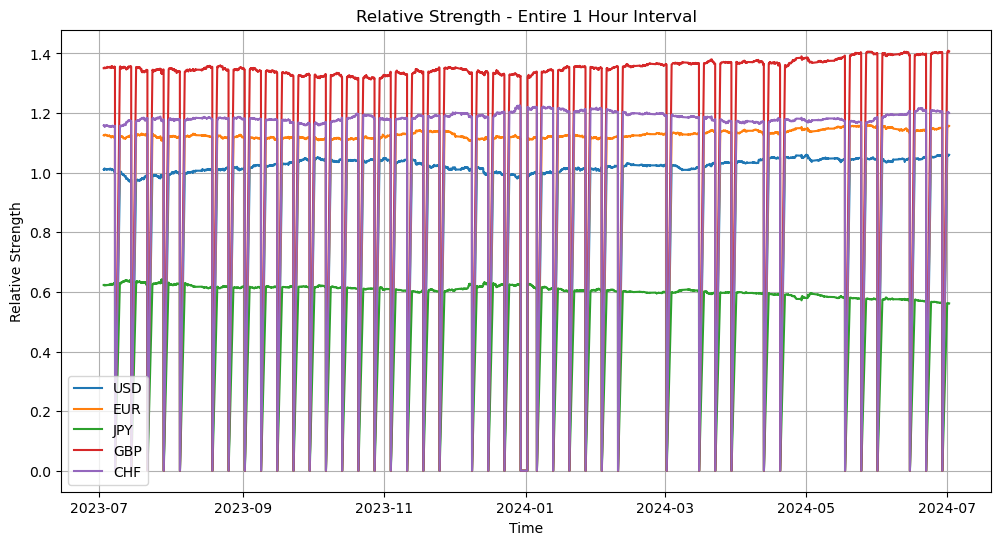

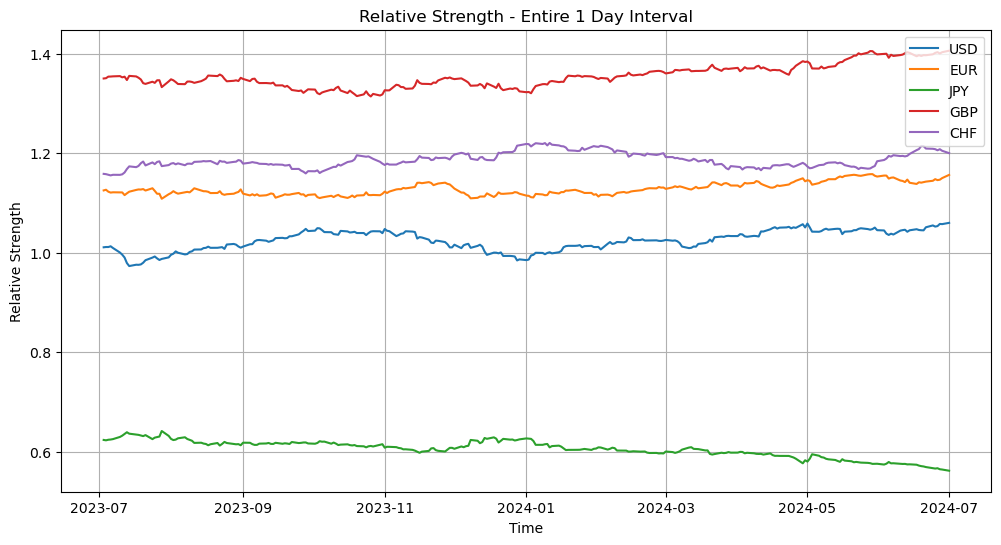

In [39]:
import matplotlib.pyplot as plt

def plot_relative_strengths(strength, title):
    plt.figure(figsize=(12, 6))
    for currency in strength.columns:
        plt.plot(strength.index, strength[currency], label=currency)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Relative Strength')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_relative_strengths(strength_1h, 'Relative Strength - Entire 1 Hour Interval')
plot_relative_strengths(strength_1d, 'Relative Strength - Entire 1 Day Interval')
